# Toy OCR Comparison: PaddleOCR vs Qwen3-VL on Scanned Traditional Chinese Book Pages

This notebook compares two open-source OCR approaches on a scanned PDF page from an old Traditional Chinese book:

1. **PaddleOCR** — classical OCR pipeline baseline.
2. **Qwen3-VL via MLX-VLM** — vision-language model OCR baseline, optimized for Apple Silicon.

Designed for Apple Silicon, such as a Mac M4 with 32GB unified memory.

## What this notebook does

- Converts a scanned PDF page into an image.
- Resizes/preprocesses the image for stable inference.
- Runs PaddleOCR using `predict()` when available, with fallback to `ocr()`.
- Runs Qwen3-VL with a prompt tailored for vertical Traditional Chinese old-book scans.
- Lets you paste manual ground truth.
- Computes character error rate (CER).
- Displays side-by-side outputs.

For a clean toy project, start with one page. Later, try cropped columns or lines.

## 1. Install dependencies

Run this once. Restart the kernel afterward if needed.

In [1]:
# Uncomment and run as needed.
# !pip install -U pip
# !pip install "numpy<2.4"
# !pip install paddleocr paddlepaddle
# !pip install -U mlx mlx-vlm transformers huggingface_hub
# !pip install pymupdf pillow matplotlib pandas rapidfuzz jupyter


## 2. Imports and configuration

In [3]:
from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageEnhance
import matplotlib.pyplot as plt

try:
    import fitz  # PyMuPDF
except ImportError:
    fitz = None

PDF_PATH = Path("input.pdf")      # Replace with your scanned PDF path
PAGE_INDEX = 0                    # 0 = first page
WORK_DIR = Path("ocr_toy_outputs")
WORK_DIR.mkdir(exist_ok=True)

MAX_IMAGE_WIDTH_FOR_VLM = 1600
MAX_IMAGE_WIDTH_FOR_PADDLE = 2200

# Change this if this model ID is unavailable in your environment.
# On Mac M4/32GB, prefer a 4-bit 4B or 8B MLX model.
#QWEN_MODEL_ID = "mlx-community/Qwen3-VL-8B-Instruct-4bit"
# QWEN_MODEL_ID = "mlx-community/Qwen3-VL-8B-Instruct-8bit"
#QWEN_MODEL_ID = "mlx-community/Qwen3-VL-8B-Thinking-8bit"
QWEN_MODEL_ID = "qwen3-vl:8b-instruct"
print("Work dir:", WORK_DIR.resolve())


Work dir: /Users/wwei/Documents/LLM_ocr/ocr_toy_outputs


## 3. Utility functions

In [4]:
def show_image(img, title=None, figsize=(10, 12)):
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()


def convert_pdf_page_to_image(pdf_path: Path, page_index: int = 0, dpi: int = 250) -> Path:
    """Convert one PDF page to a PNG image using PyMuPDF."""
    if fitz is None:
        raise ImportError("PyMuPDF is not installed. Run: pip install pymupdf")
    if not pdf_path.exists():
        raise FileNotFoundError(f"PDF not found: {pdf_path}")

    doc = fitz.open(str(pdf_path))
    page = doc[page_index]
    zoom = dpi / 72
    mat = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    out_path = WORK_DIR / f"page_{page_index+1}_dpi{dpi}.png"
    pix.save(str(out_path))
    doc.close()
    return out_path


def resize_image_keep_aspect(image_path: Path, max_width: int, suffix: str) -> Path:
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    if w <= max_width:
        out = WORK_DIR / f"{image_path.stem}_{suffix}.png"
        img.save(out)
        return out
    new_h = int(h * max_width / w)
    resized = img.resize((max_width, new_h), Image.Resampling.LANCZOS)
    out = WORK_DIR / f"{image_path.stem}_{suffix}_w{max_width}.png"
    resized.save(out)
    return out


def simple_preprocess_for_old_scan(image_path: Path, suffix="preprocessed") -> Path:
    """Light preprocessing: grayscale, autocontrast, slight contrast boost."""
    img = Image.open(image_path).convert("RGB")
    gray = ImageOps.grayscale(img)
    gray = ImageOps.autocontrast(gray)
    gray = ImageEnhance.Contrast(gray).enhance(1.25)
    rgb = gray.convert("RGB")
    out = WORK_DIR / f"{image_path.stem}_{suffix}.png"
    rgb.save(out)
    return out



import re

def normalize_text_for_cer(text):   
    if text is None:
        return ""
    
    s = str(text)
    
    # Normalize whitespace
    s = re.sub(r"\s+", "", s)
    
    # Optional: remove some punctuation
    # Keep this conservative for historical texts
    s = re.sub(r"[，。、；：「」『』（）()]", "", s)
    
    return s




def levenshtein_distance(a: str, b: str) -> int:
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        current = [i]
        for j, cb in enumerate(b, 1):
            insertions = previous[j] + 1
            deletions = current[j - 1] + 1
            substitutions = previous[j - 1] + (ca != cb)
            current.append(min(insertions, deletions, substitutions))
        previous = current
    return previous[-1]


def cer(reference: str, hypothesis: str) -> float:
    ref = normalize_text_for_cer(reference)
    hyp = normalize_text_for_cer(hypothesis)
    if len(ref) == 0:
        return float("nan")
    return levenshtein_distance(ref, hyp) / len(ref)


def save_text(name: str, text: str) -> Path:
    path = WORK_DIR / name
    path.write_text(text or "", encoding="utf-8")
    return path


## 4. Prepare input image

Put your scanned PDF at `input.pdf`, or change `PDF_PATH` above. If you already have an image, skip PDF conversion and set `raw_image_path` manually.

Raw image: ocr_toy_outputs/page_1_dpi250.png
Preprocessed: ocr_toy_outputs/page_1_dpi250_preprocessed.png
Paddle image: ocr_toy_outputs/page_1_dpi250_preprocessed_paddle_w2200.png
Qwen image: ocr_toy_outputs/page_1_dpi250_preprocessed_vlm_w1600.png
Qwen image size: (1600, 2581)


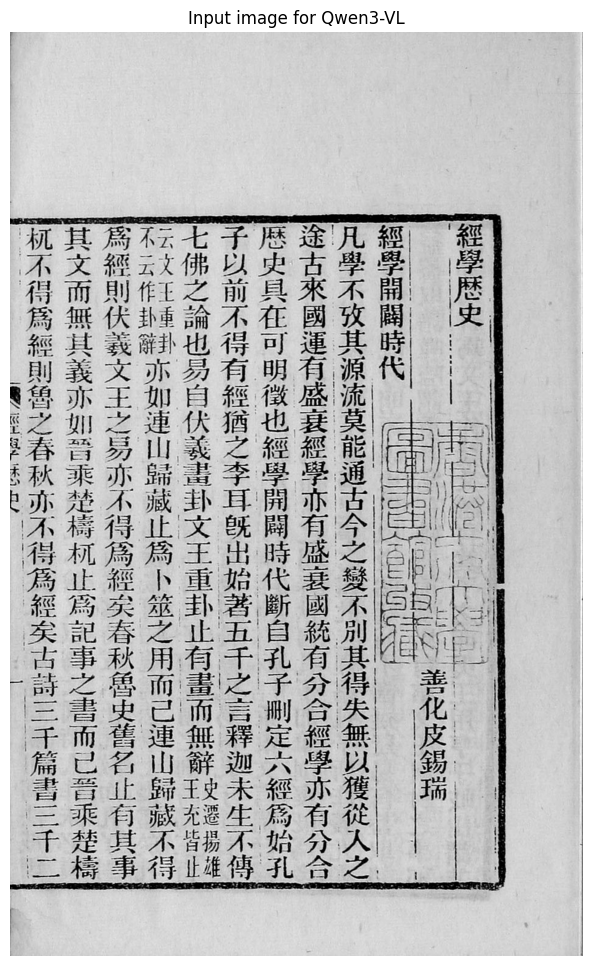

In [5]:
raw_image_path = convert_pdf_page_to_image(PDF_PATH, PAGE_INDEX, dpi=250)
print("Raw image:", raw_image_path)

preprocessed_path = simple_preprocess_for_old_scan(raw_image_path)
paddle_image_path = resize_image_keep_aspect(preprocessed_path, MAX_IMAGE_WIDTH_FOR_PADDLE, "paddle")
vlm_image_path = resize_image_keep_aspect(preprocessed_path, MAX_IMAGE_WIDTH_FOR_VLM, "vlm")

print("Preprocessed:", preprocessed_path)
print("Paddle image:", paddle_image_path)
print("Qwen image:", vlm_image_path)

img = Image.open(vlm_image_path)
print("Qwen image size:", img.size)
show_image(img, title="Input image for Qwen3-VL")


## 5. Tesseract OCR

In [6]:
from pathlib import Path
from PIL import Image
import pytesseract
import time

def run_tesseract_ocr(
    image_path: Path,
    lang: str = "chi_tra",
    psm: int = 5,
    oem: int = 1,
    verbose: bool = True,
):
    """
    Run Tesseract OCR on a Traditional Chinese scanned page.

    psm=5: assume a single uniform block of vertically aligned text.
    psm=6: assume a single uniform block of text.
    psm=11: sparse text.
    """
    image_path = Path(image_path)

    if verbose:
        print(f"Running Tesseract on: {image_path}")
        print(f"Language: {lang}")
        print(f"PSM: {psm}, OEM: {oem}")

    img = Image.open(image_path).convert("RGB")

    config = f"--oem {oem} --psm {psm}"

    start = time.time()

    text = pytesseract.image_to_string(
        img,
        lang=lang,
        config=config,
    )

    elapsed = time.time() - start

    if verbose:
        print(f"Tesseract finished in {elapsed:.2f} seconds")
        print("--- Tesseract OCR preview ---")
        print(text[:1000])

    return text

In [7]:
tesseract_text = run_tesseract_ocr(
    image_path=paddle_image_path,
    lang="chi_tra",
    psm=5,
    oem=1,
    verbose=True,
)

save_text("tesseract_output_psm5.txt", tesseract_text)

Running Tesseract on: ocr_toy_outputs/page_1_dpi250_preprocessed_paddle_w2200.png
Language: chi_tra
PSM: 5, OEM: 1
Tesseract finished in 2.28 seconds
--- Tesseract OCR preview ---
        店廬店廚 計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計計于于于于于于于卅0 上
人 ITHIIZEI ee較加襄
iomtagll

亡勤點中大之 〔呈 [本
av生几只記帳字全和)

只生友角本比塌移杏旨也《N鉛KK寺打呻素取信纜)N|
ae和uiacilistliEitnecellAIEIKSIAMANYitUEMAY同
幽扑品過宮四康司還著啃攻堅宛守名則二軍條伙還發及戰
引信宜人長唾寢主舞八林點品于彼觀還攻逢估器當藤直灰時
1_/ 047人!人 ,乙   11ifml1,-三1   TA   ae  也@ 號信二

蕊全NN委司嗆寢盡深山而伙出机而直志欄茵陛枝市表亞二|
由信和還才慘早天三眉窒如僱全山仙基刁蔬正怕引窟胡中
緞茲襄玉灼民出NN史長K軒假訕從居家中下二二寢擴生
入選民陛了漁愉景有由替獎太如候補了和貼刁記肥此壹屁
HIESINauieSEAABISEKAEIEEIIIRIUIIIIU加有



PosixPath('ocr_toy_outputs/tesseract_output_psm5.txt')

## 5. PaddleOCR inference

This is the classical OCR baseline. The code tries `predict()` first and falls back to the deprecated `ocr()` API only if needed. It also forces Chinese OCR with `lang="ch"`.

In [45]:
from pathlib import Path
import warnings
import time
from tqdm.auto import tqdm

def run_paddleocr(image_path: Path, verbose: bool = True):
    from paddleocr import PaddleOCR

    init_errors = []
    ocr = None

    init_candidates = [
        dict(lang="ch", ocr_version="PP-OCRv5", use_angle_cls=True),
        dict(lang="ch", use_angle_cls=True),
        dict(lang="ch"),
    ]

    for kwargs in tqdm(init_candidates, desc="Initializing PaddleOCR", disable=not verbose):
        try:
            if verbose:
                print("Trying PaddleOCR init:", kwargs)
            ocr = PaddleOCR(**kwargs)
            break
        except Exception as e:
            init_errors.append((kwargs, repr(e)))
            ocr = None

    if ocr is None:
        raise RuntimeError(f"Failed to initialize PaddleOCR. Errors: {init_errors}")

    start = time.time()

    try:
        if verbose:
            print("Running PaddleOCR with predict()...")
        result = ocr.predict(str(image_path))
        api_used = "predict"
    except Exception as e:
        if verbose:
            print("predict() failed, falling back to ocr.ocr(). Error:", repr(e))
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            result = ocr.ocr(str(image_path))
        api_used = "ocr"

    if verbose:
        print(f"PaddleOCR finished in {time.time() - start:.2f} seconds")

    return result, api_used

In [15]:
def extract_paddle_items(result):
    """
    Extract OCR items as:
    [{"text": str, "box": [[x,y],...], "score": float|None}]
    
    Supports common PaddleOCR 2.x and 3.x outputs.
    """
    items = []

    def add_item(text, box=None, score=None):
        text = str(text).strip()
        if text:
            items.append({
                "text": text,
                "box": box,
                "score": score,
            })

    def walk(x):
        if x is None:
            return

        if hasattr(x, "json"):
            try:
                return walk(x.json)
            except Exception:
                pass

        if hasattr(x, "to_dict"):
            try:
                return walk(x.to_dict())
            except Exception:
                pass

        if isinstance(x, dict):
            rec_texts = x.get("rec_texts")
            rec_scores = x.get("rec_scores")
            rec_boxes = (
                x.get("rec_boxes")
                or x.get("dt_polys")
                or x.get("rec_polys")
                or x.get("boxes")
            )

            if isinstance(rec_texts, list):
                for i, text in enumerate(rec_texts):
                    score = rec_scores[i] if isinstance(rec_scores, list) and i < len(rec_scores) else None
                    box = rec_boxes[i] if isinstance(rec_boxes, list) and i < len(rec_boxes) else None
                    add_item(text, box, score)
                return

            for v in x.values():
                if isinstance(v, (dict, list, tuple)):
                    walk(v)
            return

        # PaddleOCR 2.x common format:
        # [[box], [text, score]]
        if isinstance(x, (list, tuple)):
            if (
                len(x) == 2
                and isinstance(x[0], (list, tuple))
                and isinstance(x[1], (list, tuple))
                and len(x[1]) >= 1
                and isinstance(x[1][0], str)
            ):
                text = x[1][0]
                score = x[1][1] if len(x[1]) > 1 else None
                box = x[0]
                add_item(text, box, score)
                return

            for item in x:
                walk(item)

    walk(result)
    return items

In [16]:
import re

def is_probably_chinese_text(text):
    """
    Heuristic filter:
    keep text that is mostly Chinese/CJK characters.
    """
    if not text:
        return False

    chinese_chars = re.findall(
        r"[\u3400-\u4dbf\u4e00-\u9fff\uf900-\ufaff]",
        text,
    )

    return len(chinese_chars) >= max(1, len(text) * 0.4)


def filter_paddle_items(
    items,
    min_score: float = 0.45,
):
    """
    Remove low-confidence garbage OCR detections.
    """
    filtered = []

    for item in items:
        text = str(item.get("text", "")).strip()
        score = item.get("score")

        if not text:
            continue

        # confidence filtering
        if score is not None and score < min_score:
            continue

        # remove obvious Latin junk/noise
        if not is_probably_chinese_text(text):
            continue

        filtered.append(item)

    return filtered

In [20]:
def box_center(box):
    """
    Return center x, center y from PaddleOCR box.
    Handles both:
    - quadrilateral: [[x1,y1], [x2,y2], ...]
    - rectangle: [x_min, y_min, x_max, y_max]
    """
    if box is None:
        return 0, 0

    try:
        # rectangle format
        if len(box) == 4 and all(isinstance(v, (int, float)) for v in box):
            x1, y1, x2, y2 = box
            return (x1 + x2) / 2, (y1 + y2) / 2

        # polygon format
        xs = [p[0] for p in box]
        ys = [p[1] for p in box]
        return sum(xs) / len(xs), sum(ys) / len(ys)
    except Exception:
        return 0, 0


def sort_vertical_right_to_left(items, column_tolerance=35):
    """
    Sort detected OCR boxes for vertical Chinese:
    columns ordered right-to-left, text within column top-to-bottom.
    """
    enriched = []
    for item in items:
        cx, cy = box_center(item.get("box"))
        enriched.append({
            **item,
            "cx": cx,
            "cy": cy,
        })

    # Sort by x descending first: right to left
    enriched.sort(key=lambda d: -d["cx"])

    columns = []
    for item in enriched:
        placed = False
        for col in columns:
            if abs(item["cx"] - col["mean_x"]) <= column_tolerance:
                col["items"].append(item)
                col["mean_x"] = sum(i["cx"] for i in col["items"]) / len(col["items"])
                placed = True
                break

        if not placed:
            columns.append({
                "mean_x": item["cx"],
                "items": [item],
            })

    # Re-sort columns right-to-left
    columns.sort(key=lambda c: -c["mean_x"])

    ordered_texts = []
    ordered_items = []

    for col in columns:
        # top-to-bottom within one vertical column
        col_items = sorted(col["items"], key=lambda d: d["cy"])
        ordered_items.extend(col_items)
        ordered_texts.append("".join(i["text"] for i in col_items))

    return "\n".join(ordered_texts), ordered_items, columns

In [21]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm


def paddle_items_with_centers(result, min_score=0.35):
    items = extract_paddle_items(result)
    items = filter_paddle_items(items, min_score=min_score)

    enriched = []
    for item in items:
        cx, cy = box_center(item.get("box"))
        if cx == 0 and cy == 0:
            continue
        enriched.append({**item, "cx": cx, "cy": cy})

    return enriched


def group_items_into_vertical_columns(items, x_tolerance=28):
    """
    Group PaddleOCR-detected text boxes into vertical columns.
    Columns are sorted right-to-left.
    Items within each column are sorted top-to-bottom.
    """
    if not items:
        return []

    # Sort right-to-left first
    items = sorted(items, key=lambda d: -d["cx"])

    columns = []

    for item in items:
        placed = False

        for col in columns:
            if abs(item["cx"] - col["mean_x"]) <= x_tolerance:
                col["items"].append(item)
                col["mean_x"] = np.mean([i["cx"] for i in col["items"]])
                placed = True
                break

        if not placed:
            columns.append({
                "mean_x": item["cx"],
                "items": [item],
            })

    columns = sorted(columns, key=lambda c: -c["mean_x"])

    for col in columns:
        col["items"] = sorted(col["items"], key=lambda d: d["cy"])

    return columns


def text_from_vertical_columns(columns):
    col_texts = []

    for col in columns:
        col_text = "".join(item["text"] for item in col["items"])
        col_texts.append(col_text)

    return "\n".join(col_texts)


def visualize_paddle_columns(image_path, columns, figsize=(8, 12)):
    img = Image.open(image_path).convert("RGB")

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.set_title("PaddleOCR detected boxes grouped into vertical columns")

    for col_idx, col in enumerate(columns, start=1):
        for item in col["items"]:
            box = item.get("box")
            if box is None:
                continue

            try:
                # rectangle [x1,y1,x2,y2]
                if len(box) == 4 and all(isinstance(v, (int, float)) for v in box):
                    x1, y1, x2, y2 = box
                else:
                    xs = [p[0] for p in box]
                    ys = [p[1] for p in box]
                    x1, x2 = min(xs), max(xs)
                    y1, y2 = min(ys), max(ys)

                rect = plt.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=1.2,
                )
                ax.add_patch(rect)
                ax.text(x1, y1, str(col_idx), fontsize=8)

            except Exception:
                continue

    ax.axis("off")
    plt.show()

In [22]:
main_text_crop_box = (
    0,     # left
    250,   # top
    1900,   # right
    3300, #1120,  # bottom
)

from PIL import Image
from pathlib import Path

def crop_image(image_path: Path, output_path: Path, crop_box):
    img = Image.open(image_path).convert("RGB")
    cropped = img.crop(crop_box)
    cropped.save(output_path)
    return output_path

## 6. Qwen3-VL inference using MLX-VLM

The default Qwen prompt now explicitly says the page is **vertical Traditional Chinese**, top-to-bottom columns, ordered right-to-left. This is not a prompt comparison yet; it is just the default setting.

Initializing PaddleOCR:   0%|          | 0/3 [00:00<?, ?it/s]

/var/folders/95/8lqvmbj907b_w751wgrmg9nw0000gn/T/ipykernel_12165/4067585372.py:22: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(**kwargs)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/wwei/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/wwei/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/wwei/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownloa

Trying PaddleOCR init: {'lang': 'ch', 'ocr_version': 'PP-OCRv5', 'use_angle_cls': True}
Running PaddleOCR with predict()...
PaddleOCR finished in 127.28 seconds


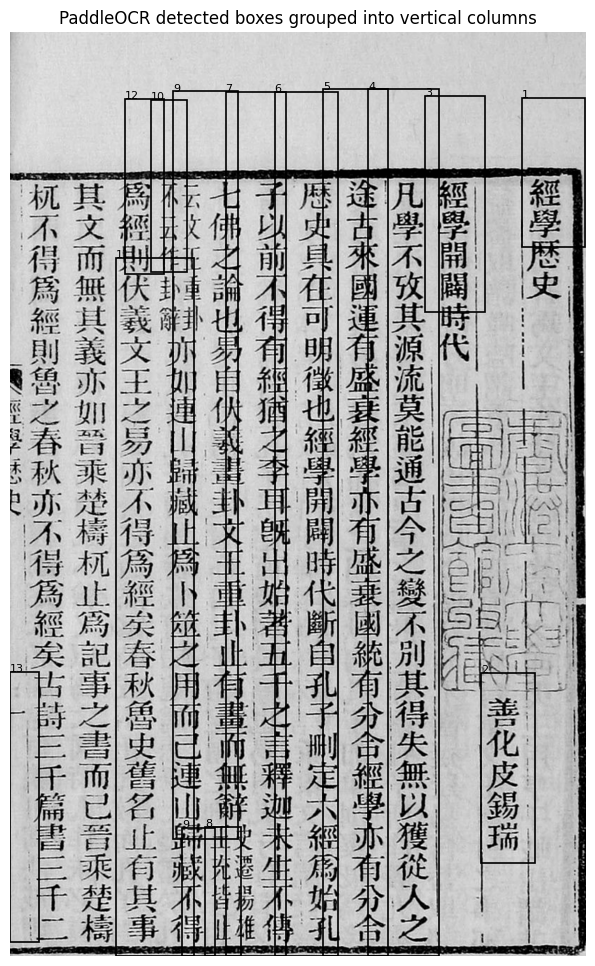

經學歷史
善化皮锡瑞
經學開闢時代
凡學不改其源流莫能通古今之變不別其得失無以獲從入之
途古來國運有盛衰經學亦有盛衰國統有分合經學亦有分合
歴史具在可明徵也經學開闢時代斷自孔子删定六經爲始孔
子以前不得有經猶之李耳出始著五千之言釋迦未生不傅
史遷揚雄
七佛之論也易自伏羲画卦文王重卦止有畫而無辭王充皆止
云文王重卦
亦如連山歸藏止爲卜之用而己連山歸藏不得
不云作卦解
2诗三千書三千一


PosixPath('ocr_toy_outputs/paddleocr_main_crop_geometry_ordered_output.txt')

In [23]:
paddle_main_crop_path = WORK_DIR / "page_main_text_crop.png"

crop_image(
    image_path=paddle_image_path,
    output_path=paddle_main_crop_path,
    crop_box=main_text_crop_box,
)

paddle_result, paddle_api_used = run_paddleocr(
    paddle_main_crop_path,
    verbose=True,
)

items = paddle_items_with_centers(
    paddle_result,
    min_score=0.35,   # lower threshold to recover more detections
)

columns = group_items_into_vertical_columns(
    items,
    x_tolerance=28,
)

visualize_paddle_columns(
    paddle_main_crop_path,
    columns,
)

paddle_text_ordered = text_from_vertical_columns(columns)

print(paddle_text_ordered[:5000])
save_text("paddleocr_main_crop_geometry_ordered_output.txt", paddle_text_ordered)

In [24]:
QWEN_VERTICAL_TRADITIONAL_CHINESE_OCR_PROMPT = """
This is a scanned page from an old Traditional Chinese book.

The text is written vertically in top-to-bottom columns ordered right-to-left.

Transcribe all visible text exactly as written.

Preserve the original reading order and line breaks.

Preserve uncommon or archaic characters exactly as they appear.
If uncertain, output the closest visible character rather than guessing.

Do not modernize characters.
Do not translate.
Do not summarize.
Do not add punctuation.
Do not explain the content.
""".strip()

print(QWEN_VERTICAL_TRADITIONAL_CHINESE_OCR_PROMPT)


This is a scanned page from an old Traditional Chinese book.

The text is written vertically in top-to-bottom columns ordered right-to-left.

Transcribe all visible text exactly as written.

Preserve the original reading order and line breaks.

Preserve uncommon or archaic characters exactly as they appear.
If uncertain, output the closest visible character rather than guessing.

Do not modernize characters.
Do not translate.
Do not summarize.
Do not add punctuation.
Do not explain the content.


In [25]:
import base64
import requests
import time
from pathlib import Path

def run_qwen3_vl_ollama(
    image_path: Path,
    model_id: str = "qwen3-vl:8b-instruct",
    prompt: str = "",
    max_tokens: int = 512,
    verbose: bool = True,
):
    """Run Qwen3-VL through Ollama. More stable than mlx-vlm for this setup."""
    if verbose:
        print(f"Using model: {model_id}")
        print(f"Image: {image_path}")
        print("Encoding image...")
    image_b64 = base64.b64encode(Path(image_path).read_bytes()).decode("utf-8")

    payload = {
        "model": model_id,
        "prompt": prompt,
        "images": [image_b64],
        "stream": False,
        "options": {
            "temperature": 0.0,
            "num_predict": max_tokens,
        },
    }
    if verbose:
        print("Sending request to Ollama...")
        start_time = time.time()

    response = requests.post(
        "http://localhost:11434/api/generate",
        json=payload,
        timeout=600,
    )
    if verbose:
        elapsed = time.time() - start_time
        print(f"Completed in {elapsed:.2f} seconds")
        
    response.raise_for_status()
    result = response.json()["response"]

    # if verbose:
    #     print("\n--- OCR Preview ---")
    #     print(result[:500])

    return result

In [26]:
try:
    qwen_text = run_qwen3_vl_ollama(
    image_path=vlm_image_path,
    model_id=QWEN_MODEL_ID,
    prompt=QWEN_VERTICAL_TRADITIONAL_CHINESE_OCR_PROMPT,
    max_tokens=512,
    verbose=True,
    )
except Exception as e:
    qwen_text = ""
    print("Qwen3-VL inference failed.")
    print("Error:", repr(e))
    print("Fix suggestions:")
    print("1. Confirm mlx-vlm is installed: pip install -U mlx-vlm")
    print("2. Confirm QWEN_MODEL_ID is an available MLX-compatible Qwen3-VL model.")
    print("3. Try a smaller 4B quantized model if memory is tight.")

print("--- Qwen3-VL text ---")
print(qwen_text[:5000])
save_text("qwen3vl_output.txt", qwen_text)


Using model: qwen3-vl:8b-instruct
Image: ocr_toy_outputs/page_1_dpi250_preprocessed_vlm_w1600.png
Encoding image...
Sending request to Ollama...
Completed in 44.26 seconds
--- Qwen3-VL text ---
經學歷史
善化皮錫瑞
經學開闢時代
凡學不攷其源流莫能通古今之變不別其得失無以獲從入之
途古來國運有盛衰經學亦有盛衰國統有分合經學亦有分合
歷史具在可明徵也經學開闢時代斷自孔子刪定六經為始孔
子以前不得有經猶之李耳既出始著五千之言釋迦未生不傳
七佛之論也易自伏義畫卦文王重卦止有畫而無辭史遷揚雄
云文王重卦亦如連山歸藏止為卜筮之用而已連山歸藏不得
不云作卦辭為經則伏義文王之易亦不得為經矣春秋魯史舊名止有其事
其文而無其義亦如晉乘楚檮杌止為記事之書而已晉乘楚檮
杌不得為經則魯之春秋亦不得為經矣古詩三千篇書三千二


PosixPath('ocr_toy_outputs/qwen3vl_output.txt')

## 7. Add manual ground truth

Paste your manual transcription here. For a toy project, one vertical column is enough to start.

In [38]:
GROUND_TRUTH = """
經學歷史
善化皮錫瑞
經學開闢時代
凡學不攷其源流莫能通古今之變不別其得失無以獲從入之
途古來國運有盛衰經學亦有盛衰國統有分合經學亦有分合
歷史具在可明徵也經學開闢時代斷自孔子刪定六經為始孔
子以前不得有經猶之李耳既出始著五千之言釋迦未生不傳
七佛之論也易自伏義畫卦文王重卦止有畫而無辭
史遷揚雄王充皆止云文王重卦不云作卦辭
亦如連山歸藏止為卜筮之用而已連山歸藏不得
為經則伏義文王之易亦不得為經矣春秋魯史舊名止有其事
其文而無其義亦如晉乘楚檮杌止為記事之書而已晉乘楚檮
杌不得為經則魯之春秋亦不得為經矣古詩三千篇書三千二
""".strip()

print("Ground truth length:", len(normalize_text_for_cer(GROUND_TRUTH)))


Ground truth length: 249


## 8. Compute CER and compare outputs

In [39]:
gt_norm = normalize_text_for_cer(GROUND_TRUTH)

results = []

for model_name, output in [
    ("Tesseract", tesseract_text),
    ("PaddleOCR", paddle_text_ordered),
    ("Qwen3-VL", qwen_text),
]:
    output = output or ""
    output_norm = normalize_text_for_cer(output)

    results.append({
        "model": model_name,
        "raw_output_chars": len(output),
        "normalized_output_chars": len(output_norm),
        "CER": cer(gt_norm, output_norm) if gt_norm else np.nan,
    })

results_df = pd.DataFrame(results)
results_df


,model,raw_output_chars,normalized_output_chars,CER
0,Tesseract,464,416,1.642570
1,PaddleOCR,192,180,0.377510
2,Qwen3-VL,256,245,0.056225


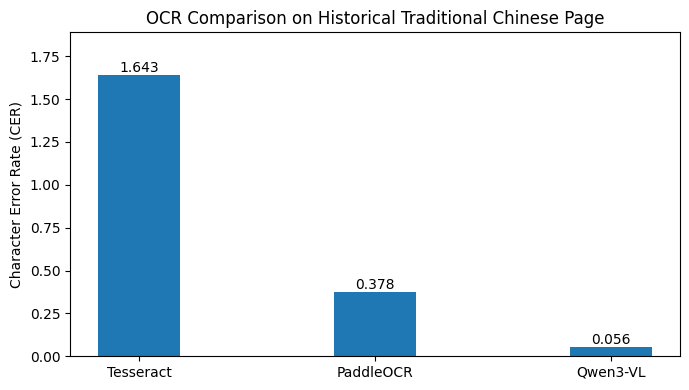

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = results_df.copy()

x = np.arange(len(plot_df))

plt.figure(figsize=(7, 4))

plt.bar(
    x,
    plot_df["CER"],
    width=0.35,      # narrower bars
)

plt.xticks(x, plot_df["model"])
plt.ylabel("Character Error Rate (CER)")
plt.title("OCR Comparison on Historical Traditional Chinese Page")
plt.ylim(0, max(plot_df["CER"]) * 1.15)
for i, row in plot_df.iterrows():
    plt.text(
        x[i],
        row["CER"],
        f"{row['CER']:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [43]:
print("=== Ground Truth ===")
print(GROUND_TRUTH[:3000])

print("=== PaddleOCR ===")
print(paddle_text_ordered[:3000])

print("=== Qwen3-VL ===")
print(qwen_text[:3000])


=== Ground Truth ===
經學歷史
善化皮錫瑞
經學開闢時代
凡學不攷其源流莫能通古今之變不別其得失無以獲從入之
途古來國運有盛衰經學亦有盛衰國統有分合經學亦有分合
歷史具在可明徵也經學開闢時代斷自孔子刪定六經為始孔
子以前不得有經猶之李耳既出始著五千之言釋迦未生不傳
七佛之論也易自伏義畫卦文王重卦止有畫而無辭
史遷揚雄王充皆止云文王重卦不云作卦辭
亦如連山歸藏止為卜筮之用而已連山歸藏不得
為經則伏義文王之易亦不得為經矣春秋魯史舊名止有其事
其文而無其義亦如晉乘楚檮杌止為記事之書而已晉乘楚檮
杌不得為經則魯之春秋亦不得為經矣古詩三千篇書三千二
=== PaddleOCR ===
經學歷史
善化皮锡瑞
經學開闢時代
凡學不改其源流莫能通古今之變不別其得失無以獲從入之
途古來國運有盛衰經學亦有盛衰國統有分合經學亦有分合
歴史具在可明徵也經學開闢時代斷自孔子删定六經爲始孔
子以前不得有經猶之李耳出始著五千之言釋迦未生不傅
史遷揚雄
七佛之論也易自伏羲画卦文王重卦止有畫而無辭王充皆止
云文王重卦
亦如連山歸藏止爲卜之用而己連山歸藏不得
不云作卦解
2诗三千書三千一
=== Qwen3-VL ===
經學歷史
善化皮錫瑞
經學開闢時代
凡學不攷其源流莫能通古今之變不別其得失無以獲從入之
途古來國運有盛衰經學亦有盛衰國統有分合經學亦有分合
歷史具在可明徵也經學開闢時代斷自孔子刪定六經為始孔
子以前不得有經猶之李耳既出始著五千之言釋迦未生不傳
七佛之論也易自伏義畫卦文王重卦止有畫而無辭史遷揚雄
云文王重卦亦如連山歸藏止為卜筮之用而已連山歸藏不得
不云作卦辭為經則伏義文王之易亦不得為經矣春秋魯史舊名止有其事
其文而無其義亦如晉乘楚檮杌止為記事之書而已晉乘楚檮
杌不得為經則魯之春秋亦不得為經矣古詩三千篇書三千二


## 9. Save comparison report

In [44]:
report = {
    "pdf_path": str(PDF_PATH),
    "page_index": PAGE_INDEX,
    "raw_image_path": str(raw_image_path),
    "paddle_image_path": str(paddle_image_path),
    "vlm_image_path": str(vlm_image_path),
    "qwen_model_id": QWEN_MODEL_ID,
    "qwen_prompt": QWEN_VERTICAL_TRADITIONAL_CHINESE_OCR_PROMPT,
    "metrics": results_df.to_dict(orient="records"),
    "ground_truth": GROUND_TRUTH,
    "paddleocr_output": paddle_text_ordered,
    "qwen3vl_output": qwen_text,
}

report_path = WORK_DIR / "comparison_report.json"
report_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")

csv_path = WORK_DIR / "metrics.csv"
results_df.to_csv(csv_path, index=False)

print("Saved report:", report_path)
print("Saved metrics:", csv_path)


Saved report: ocr_toy_outputs/comparison_report.json
Saved metrics: ocr_toy_outputs/metrics.csv


## 10. Suggested next steps

After this toy version works:

1. Test one cropped vertical column instead of a full page.
2. Add a second page with worse scan quality.
3. Add reading-order notes manually: did the model preserve right-to-left columns?
4. Later, run a prompt-sensitivity experiment for Qwen3-VL.
5. Later, compare PaddleOCR preprocessing settings.

For now, keep it simple: one page, two models, one ground truth, one CER table.